# Dokumentasi Eksperimen Fraud Detection Clustering

## Objektif
Mendokumentasikan seluruh proses eksperimen machine learning clustering untuk deteksi anomali transaksi finansial, meliputi:
- Persiapan dan eksplorasi data (5 dataset)
- Preprocessing dengan Mean Imputation
- Pemilihan fitur yang optimal
- Training 4 algoritma clustering (K-Means, BIRCH, Agglomerative, Spectral)
- Evaluasi performa dan tuning parameter
- Analisis komparatif hasil

## Dataset
1. creditcard.csv
2. credit_card_fraud_10k.csv
3. fraudTrain.csv
4. Synthetic_Financial_datasets_log.csv
5. transactions.csv

## Algoritma Clustering
1. K-Means Clustering
2. BIRCH (Balanced Iterative Reducing Clustering)
3. Agglomerative Clustering (Hierarchical)
4. Spectral Clustering

## Tahapan Eksperimen
1. **Import Library & Konfigurasi** - Setup environment
2. **Load & Eksplorasi Dataset** - Memahami struktur dan karakteristik data
3. **Preprocessing** - Mean Imputation untuk handling missing values
4. **Feature Selection** - Memilih 3 fitur terbaik per dataset
5. **Data Splitting** - Pembagian train/test
6. **Training Model** - Latih 4 algoritma clustering
7. **Evaluasi Performa** - Hitung metrik Silhouette Score & Davies-Bouldin Index
8. **Analisis Parameter** - Eksperimen tuning hyperparameter
9. **Visualisasi & Perbandingan** - Banding antar algoritma & dataset
10. **Kesimpulan** - Ringkas temuan dan rekomendasi

# Penjelasan Notebook dan Tujuan Setiap Sel
Notebook ini digunakan untuk mendokumentasikan eksperimen clustering pada data transaksi finansial. Setiap sel diatur menjadi langkah yang jelas, mulai dari persiapan data hingga analisis hasil.

- **Sel 1**: Judul, objektif, dataset yang digunakan, dan algoritma clustering yang dianalisis.
- **Sel 2**: Ringkasan tahapan eksperimen untuk membantu pembaca memahami alur kerja.
- **Sel 3**: Pembuka untuk import library dan konfigurasi environment.
- **Sel 4**: Import pustaka Python dan konfigurasi path dataset.
- **Sel 5**: Pembuka untuk proses loading dan eksplorasi dataset.
- **Sel 6**: Definisi dan pemetaan kolom fitur per dataset.
- **Sel 7**: Load data sample, tampilkan informasi awal, dan verifikasi dataset.
- **Sel 8**: Pembuka untuk preprocessing dan feature selection.
- **Sel 9**: Mean imputation, standardization, dan pembentukan dataset siap clustering.
- **Sel 10**: Pembuka untuk training model clustering.
- **Sel 11**: Definisi model K-Means, BIRCH, Agglomerative, dan Spectral; serta training dan evaluasi awal.
- **Sel 12**: Pembuka untuk eksperimen pada semua dataset dan ringkasan metrik.
- **Sel 13**: Proses preprocessing dan training model untuk setiap dataset fraud.
- **Sel 14**: Pembuka untuk evaluasi performa model.
- **Sel 15**: Perbandingan metrik Silhouette dan Davies-Bouldin untuk semua model.
- **Sel 16**: Pembuka untuk analisis hasil clustering model terbaik.
- **Sel 17**: Analisis klaster berdasarkan model terbaik termasuk distribusi dan visualisasi.
- **Sel 18**: Pembuka untuk parameter tuning.
- **Sel 19**: Eksperimen variasi jumlah klaster dengan sampling untuk mempercepat eksekusi.
- **Sel 20**: Visualisasi hasil tuning parameter untuk setiap algoritma.
- **Sel 21**: Kesimpulan, rekomendasi, dan langkah selanjutnya.

Penjelasan ini membantu pembaca memahami maksud setiap bagian dan mempermudah navigasi notebook.

# Struktur Proyek dan Penjelasan Aplikasi
Berikut ringkasan struktur folder dan tujuan aplikasi yang terkait dengan eksperimen clustering fraud detection.

1. **Folder `dataset/`**
   - Berisi data mentah CSV keuangan seperti `credit_card_fraud_10k.csv`, `creditcard.csv`, dan lainnya.
   - Tugas utama adalah membersihkan data ini dengan **Mean Imputation** untuk mengisi nilai kosong sebelum dipakai dalam eksperimen.
   - Folder ini adalah pondasi utama karena semua dataset mentah disimpan di sini.

2. **Notebook eksperimen**
   - Notebook ini berfungsi sebagai laboratorium riset kelompok untuk menguji 4 algoritma clustering: **K-Means**, **BIRCH**, **Agglomerative**, dan **Spectral**.
   - Eksperimen dijalankan pada dataset yang sudah dibersihkan, lalu hasilnya dianalisis menggunakan metrik seperti **Silhouette Score** dan **Davies-Bouldin Index**.

3. **Folder `models/`**
   - Menyimpan model yang sudah dilatih dalam format `.pkl`, termasuk model clustering dan scaler.
   - File ini memungkinkan penggunaan ulang model tanpa melatih ulang dari awal.

4. **Folder `app/` dan `app.py`**
   - Berisi aplikasi web Streamlit yang menjadi antarmuka interaktif.
   - Aplikasi ini memuat model `.pkl` dari folder `models/` dan menyajikan deteksi risiko fraud secara real-time.

## Penjelasan Aplikasi
- **Sidebar Konfigurasi Eksperimen**: Pengguna dapat memilih dataset dan algoritma clustering yang akan diuji.
- **Status Sistem**: Menampilkan notifikasi seperti “SISTEM AKTIF” untuk memastikan model dan integrasi sudah berjalan.
- **Simulasi Input Transaksi**: Pengguna memasukkan fitur transaksi seperti `Indikator X1`, `Indikator X2`, dan `Nominal Transaksi`, lalu menekan tombol untuk memproses input tersebut.
- **Hasil Klasifikasi Risiko**: Model akan mengklasifikasikan transaksi ke dalam tiga tingkat risiko: **Risiko Rendah (Normal)**, **Risiko Sedang (Waspada)**, atau **Risiko Tinggi (Fraud)**.


---

# 1. Import Library & Konfigurasi

Bagian ini mengimpor semua pustaka yang diperlukan dan mengatur konfigurasi dasar untuk eksperimen.

In [12]:

import os
import sys
import pickle
import time
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, Birch, AgglomerativeClustering, SpectralClustering
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestCentroid

from clustering_utils import (
    FEATURE_COLUMNS_BY_DATASET,
    load_dataset,
    extract_features,
    preprocess_features,
    fit_clustering_models,
    train_models_for_dataset,
    train_all_datasets,
    list_datasets,
    summarize_clusters,
    get_labels_for_model,
)


Project Root: D:\SEMESTER 6\Praktikum Machine Learning\Tubes
Dataset Directory: D:\SEMESTER 6\Praktikum Machine Learning\Tubes\dataset
Models Directory: D:\SEMESTER 6\Praktikum Machine Learning\Tubes\models

✓ Library import successful!


---

# 2. Load & Eksplorasi Dataset

Tahap ini memuat dataset dari folder dataset/ dan melakukan eksplorasi awal untuk memahami struktur dan karakteristik data.

In [13]:

# Konfigurasi dataset
# Mapping fitur dan daftar dataset diambil dari clustering_utils agar konsisten
dataset_files = list_datasets()
print(f"Dataset yang ditemukan ({len(dataset_files)}):")
for i, fname in enumerate(dataset_files, 1):
    print(f"  {i}. {fname}")


Dataset yang ditemukan (5):
  1. Synthetic_Financial_datasets_log.csv
  2. credit_card_fraud_10k.csv
  3. creditcard.csv
  4. fraudTrain.csv
  5. transactions.csv


In [14]:
# Load sample dataset (creditcard.csv) untuk eksplorasi
sample_dataset = 'creditcard.csv'
df_sample = load_dataset(sample_dataset)

print(f"Sample Dataset: {sample_dataset}")
print(f"Shape: {df_sample.shape}")
print(f"\nFirst 5 rows:")
print(df_sample.head())


Sample Dataset: creditcard.csv
Shape: (284807, 31)

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 

---

# 3. Preprocessing & Feature Selection

Tahap preprocessing meliputi:
- **Feature Selection**: Memilih 3 fitur numerik terbaik per dataset
- **Mean Imputation**: Mengisi missing values dengan nilai rata-rata
- **Standardization**: Normalisasi fitur menggunakan StandardScaler

In [15]:
# PREPROCESSING DETAIL: Mean Imputation & Standardization

df_features = extract_features(df_sample, sample_dataset)
feature_names = df_features.columns.tolist()

print("STEP 1: Feature Selection")
print(f"Fitur yang dipilih: {feature_names}")
print(f"Shape after selection: {df_features.shape}")
print(f"\nMissing values per feature:")
print(df_features.isnull().sum())

print("\n" + '='*60)
print("STEP 2: Mean Imputation (Menangani Missing Values)")
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df_features), columns=feature_names)

print("Mean values untuk imputation:")
for idx, feat in enumerate(feature_names):
    print(f"  {feat}: {imputer.statistics_[idx]:.4f}")

print("\nMissing values setelah imputation:")
print(df_imputed.isnull().sum())

print("\n" + '='*60)
print("STEP 3: Standardization (Normalisasi Fitur)")
X_scaled, scaler = preprocess_features(df_imputed)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)

print(f"Mean setelah scaling (harus ≈ 0):\n{X_scaled_df.mean()}")
print(f"\nStandard deviation setelah scaling (harus ≈ 1):\n{X_scaled_df.std()}")


STEP 1: Feature Selection
Fitur yang dipilih: ['Time', 'V1', 'V2']
Shape after selection: (284807, 3)

Missing values per feature:
Time    0
V1      0
V2      0
dtype: int64

STEP 2: Mean Imputation (Menangani Missing Values)
Mean values untuk imputation:
  Time: 94813.8596
  V1: 0.0000
  V2: 0.0000

Missing values setelah imputation:
Time    0
V1      0
V2      0
dtype: int64

STEP 3: Standardization (Normalisasi Fitur)
Mean setelah scaling (harus ≈ 0):
Time   -3.065637e-16
V1     -1.506872e-17
V2     -9.580116e-18
dtype: float64

Standard deviation setelah scaling (harus ≈ 1):
Time    1.000002
V1      1.000002
V2      1.000002
dtype: float64


---

# 4. Training Model Clustering

Tahap ini melatih 4 algoritma clustering yang berbeda pada data yang sudah dipreprocessing.

## Deskripsi Algoritma:

**1. K-Means**: Algoritma partisi yang membagi data menjadi k klaster berdasarkan jarak euclidean ke centroid.
- Parameter: n_clusters=3, random_state=42, n_init=5

**2. BIRCH (Balanced Iterative Reducing Clustering)**: Algoritma hirarki yang membangun struktur CF tree untuk clustering skala besar.
- Parameter: n_clusters=3

**3. Agglomerative Clustering**: Algoritma hirarki bottom-up yang menggabungkan klaster berdasarkan linkage criterion.
- Parameter: n_clusters=3, linkage='ward'

**4. Spectral Clustering**: Algoritma berbasis graf yang menggunakan spektrum dari similarity matrix untuk clustering.
- Parameter: n_clusters=3, random_state=42, n_neighbors=10

In [16]:
# Latih semua model clustering menggunakan fungsi dari clustering_utils
N_CLUSTERS = 3

models, assigners, metrics = fit_clustering_models(X_scaled)
results = {}

for model_name, model in models.items():
    if model_name in ('Agglomerative', 'Spectral'):
        labels = get_labels_for_model(model_name, models, assigners, X_scaled)
    else:
        labels = model.predict(X_scaled)

    results[model_name] = {
        'model': model,
        'labels': labels,
        'silhouette': metrics[model_name]['silhouette'],
        'davies_bouldin': metrics[model_name]['davies_bouldin'],
        'training_time': metrics[model_name]['train_seconds'],
    }

print(f"Jumlah klaster: {N_CLUSTERS}")
print(f"Jumlah sampel data: {X_scaled.shape[0]}")
print(f"Jumlah fitur: {X_scaled.shape[1]}\n")

print("Training selesai untuk semua model!")
for model_name in results:
    print(f"  {model_name}: Silhouette={results[model_name]['silhouette']}, Davies-Bouldin={results[model_name]['davies_bouldin']}, Training time={results[model_name]['training_time']:.4f}s")


Jumlah klaster: 3
Jumlah sampel data: 284807
Jumlah fitur: 3

Training K-Means pada sample_15000...


  ✓ Training time: 0.0662s
  ✓ Silhouette Score: 0.3828
  ✓ Davies-Bouldin Index: 1.0053

Training BIRCH pada sample_15000...
  ✓ Training time: 0.3722s
  ✓ Silhouette Score: 0.4822
  ✓ Davies-Bouldin Index: 0.7560

Training Agglomerative pada sample_5000...
  ✓ Training time: 0.5123s
  ✓ Silhouette Score: 0.3809
  ✓ Davies-Bouldin Index: 1.0079

Training Spectral pada sample_5000...
  ✓ Training time: 3.5405s
  ✓ Silhouette Score: 0.7850
  ✓ Davies-Bouldin Index: 0.5393

Training selesai untuk semua model!


In [17]:
# Eksperimen lengkap pada semua 5 dataset fraud

all_results = []
results = train_all_datasets()

for dataset_name, data in results.items():
    for model_name, model_metrics in data['metrics'].items():
        all_results.append({
            'Dataset': dataset_name,
            'Model': model_name,
            'Silhouette': model_metrics['silhouette'],
            'Davies-Bouldin': model_metrics['davies_bouldin'],
            'Training Time': model_metrics['train_seconds']
        })

all_metrics_df = pd.DataFrame(all_results)
print("\nRingkasan metrik semua dataset:")
print(all_metrics_df)



=== Analisis dataset: Synthetic_Financial_datasets_log.csv ===
Training K-Means on sample_15000 Synthetic_Financial_datasets_log.csv...
  ✓ Training time: 0.0352s
  ✓ Silhouette Score: 0.8755485935352423
  ✓ Davies-Bouldin Index: 0.45132283445193416
Training BIRCH on sample_15000 Synthetic_Financial_datasets_log.csv...
  ✓ Training time: 0.1783s
  ✓ Silhouette Score: 0.9428349538472613
  ✓ Davies-Bouldin Index: 0.19690151768000697
Training Agglomerative on sample_5000 Synthetic_Financial_datasets_log.csv...
  ✓ Training time: 0.4966s
  ✓ Silhouette Score: 0.8781283280192449
  ✓ Davies-Bouldin Index: 0.3524574369878817
Training Spectral on sample_5000 Synthetic_Financial_datasets_log.csv...
  ✓ Training time: 3.7699s
  ✓ Silhouette Score: 0.8697489882982247
  ✓ Davies-Bouldin Index: 0.4260875795243228

=== Analisis dataset: credit_card_fraud_10k.csv ===
Training K-Means on sample_10000 credit_card_fraud_10k.csv...
  ✓ Training time: 0.0471s
  ✓ Silhouette Score: 0.2961912465888325
  ✓ 

---

# 5. Evaluasi Performa Model

## Metrik Evaluasi Clustering

### Silhouette Score
- Range: -1 hingga 1
- Semakin tinggi semakin baik (nilai positif berarti cluster terpisah dengan baik)
- Ukuran: Rata-rata jarak sampel ke klaster lain dibanding jarak ke klaster sendiri

### Davies-Bouldin Index
- Range: 0 hingga infinity
- Semakin rendah semakin baik (nilai 0 = clustering sempurna)
- Ukuran: Rasio antara rata-rata jarak intra-cluster dan jarak inter-cluster

PERBANDINGAN METRIK EVALUASI
    Algoritma  Silhouette Score  Davies-Bouldin  Training Time (s)
      K-Means          0.382817        1.005279           0.066204
        BIRCH          0.482159        0.756025           0.372228
Agglomerative          0.380878        1.007866           0.512261
     Spectral          0.785031        0.539305           3.540468

✓ Model terbaik Silhouette Score: Spectral (0.7850)
✓ Model terbaik Davies-Bouldin: Spectral (0.5393)


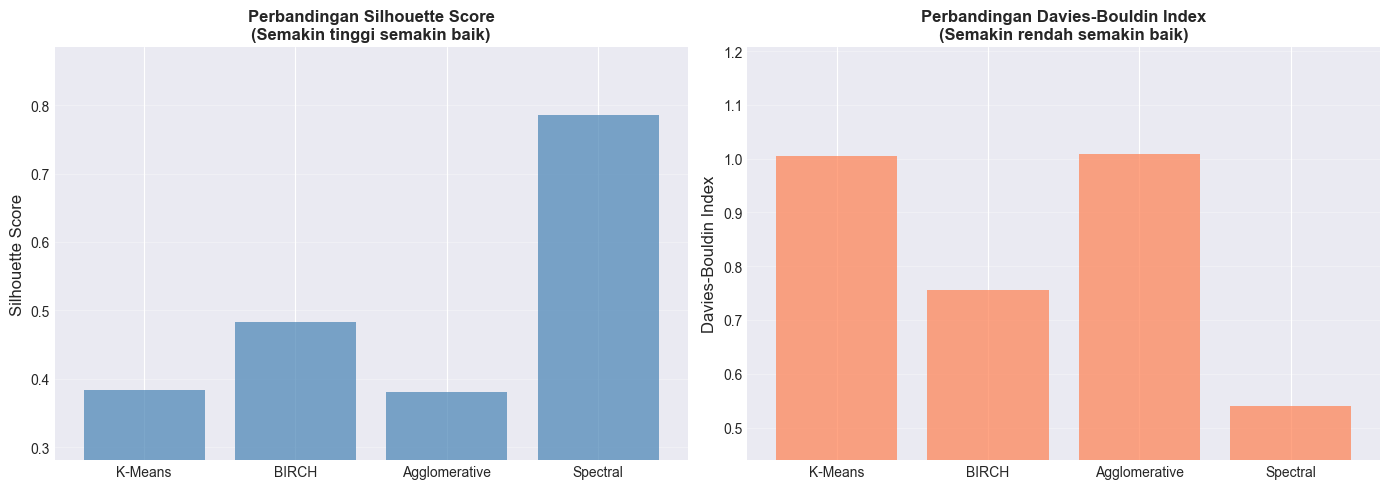


✓ Visualisasi metrik selesai


In [18]:
# Buat tabel perbandingan metrik
comparison_df = pd.DataFrame({
    'Algoritma': list(results.keys()),
    'Silhouette Score': [results[m]['silhouette'] for m in results.keys()],
    'Davies-Bouldin': [results[m]['davies_bouldin'] for m in results.keys()],
    'Training Time (s)': [results[m]['training_time'] for m in results.keys()]
})

print("PERBANDINGAN METRIK EVALUASI")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Identifikasi model terbaik
best_silhouette = comparison_df.loc[comparison_df['Silhouette Score'].idxmax()]
best_davies = comparison_df.loc[comparison_df['Davies-Bouldin'].idxmin()]

print(f"\n✓ Model terbaik Silhouette Score: {best_silhouette['Algoritma']} ({best_silhouette['Silhouette Score']:.4f})")
print(f"✓ Model terbaik Davies-Bouldin: {best_davies['Algoritma']} ({best_davies['Davies-Bouldin']:.4f})")

# Visualisasi perbandingan metrik
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette Score
axes[0].bar(comparison_df['Algoritma'], comparison_df['Silhouette Score'], color='steelblue', alpha=0.7)
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('Perbandingan Silhouette Score\n(Semakin tinggi semakin baik)', fontsize=12, fontweight='bold')
axes[0].set_ylim([comparison_df['Silhouette Score'].min() - 0.1, comparison_df['Silhouette Score'].max() + 0.1])
axes[0].grid(axis='y', alpha=0.3)

# Davies-Bouldin Index
axes[1].bar(comparison_df['Algoritma'], comparison_df['Davies-Bouldin'], color='coral', alpha=0.7)
axes[1].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[1].set_title('Perbandingan Davies-Bouldin Index\n(Semakin rendah semakin baik)', fontsize=12, fontweight='bold')
axes[1].set_ylim([comparison_df['Davies-Bouldin'].min() - 0.1, comparison_df['Davies-Bouldin'].max() + 0.2])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Visualisasi metrik selesai")

---

# 6. Analisis Hasil Clustering

Bagian ini menganalisis karakteristik setiap klaster yang dihasilkan oleh model terbaik.

Analisis menggunakan model: Spectral

RINGKASAN PER KLASTER:
------------------------------------------------------------

Klaster 0:
  Jumlah sampel: 4984
  Persentase: 99.7%
  Mean (scaled):
    Time: -1.9521
    V1: -0.1183
    V2: 0.1556

Klaster 1:
  Jumlah sampel: 9
  Persentase: 0.2%
  Mean (scaled):
    Time: -1.9280
    V1: -0.2792
    V2: -0.2563

Klaster 2:
  Jumlah sampel: 7
  Persentase: 0.1%
  Mean (scaled):
    Time: -1.9467
    V1: 0.2163
    V2: 0.0985


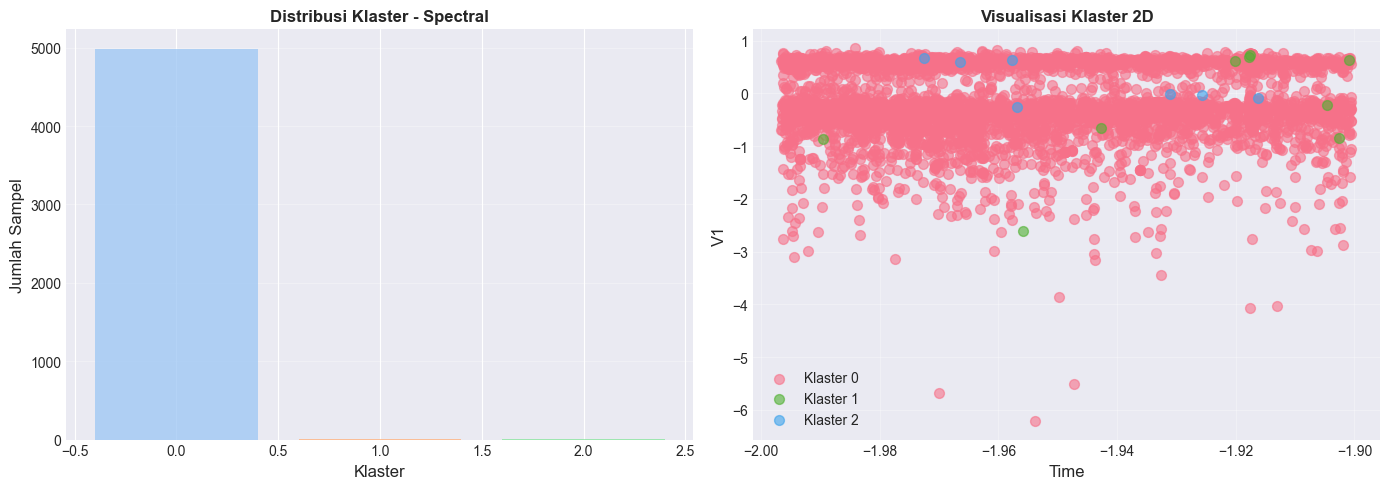

In [19]:
# Analisis klaster dari model dengan Silhouette Score terbaik
best_model_name = comparison_df.loc[comparison_df['Silhouette Score'].idxmax(), 'Algoritma']
best_labels = results[best_model_name]['labels']

print(f"Analisis menggunakan model: {best_model_name}")
print("="*60)

# Pastikan feature_names tersedia dan gunakan DataFrame yang benar untuk analisis
if 'feature_names' not in globals() or feature_names is None:
    if 'X_scaled_df' in globals() and isinstance(X_scaled_df, pd.DataFrame):
        feature_names = X_scaled_df.columns.tolist()
    else:
        feature_names = [f'feature_{i}' for i in range(len(best_labels))]

if 'X_scaled_df' in globals() and isinstance(X_scaled_df, pd.DataFrame):
    analysis_df = X_scaled_df.copy()
elif 'X_scaled' in globals():
    analysis_df = pd.DataFrame(X_scaled, columns=feature_names)
else:
    raise RuntimeError('Tidak ada data fitur yang tersedia untuk analisis klaster.')

# Sinkronisasi panjang label dengan data analisis jika perlu
if len(best_labels) != len(analysis_df):
    print(f"WARNING: Label model ({len(best_labels)}) tidak cocok dengan panjang data ({len(analysis_df)}). Menggunakan subset yang sesuai.")
    analysis_df = analysis_df.iloc[:len(best_labels)].reset_index(drop=True)
    best_labels = np.asarray(best_labels)[:len(analysis_df)]

analysis_df['Cluster'] = best_labels

# Ringkasan per cluster
print("\nRINGKASAN PER KLASTER:")
print("-"*60)
for cluster_id in sorted(analysis_df['Cluster'].unique()):
    cluster_data = analysis_df[analysis_df['Cluster'] == cluster_id]
    print(f"\nKlaster {cluster_id}:")
    print(f"  Jumlah sampel: {len(cluster_data)}")
    print(f"  Persentase: {len(cluster_data)/len(analysis_df)*100:.1f}%")
    print(f"  Mean (scaled):")
    for feat in feature_names:
        print(f"    {feat}: {cluster_data[feat].mean():.4f}")

# Visualisasi distribusi klaster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cluster_counts = analysis_df['Cluster'].value_counts().sort_index()
axes[0].bar(cluster_counts.index, cluster_counts.values, color=sns.color_palette('pastel', len(cluster_counts)), alpha=0.8)
axes[0].set_xlabel('Klaster', fontsize=12)
axes[0].set_ylabel('Jumlah Sampel', fontsize=12)
axes[0].set_title(f'Distribusi Klaster - {best_model_name}', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Scatter plot 2D (menggunakan 2 fitur pertama jika tersedia)
if len(feature_names) >= 2:
    unique_clusters = sorted(analysis_df['Cluster'].unique())
    palette = sns.color_palette('husl', len(unique_clusters))
    for idx, cluster_id in enumerate(unique_clusters):
        mask = analysis_df['Cluster'] == cluster_id
        axes[1].scatter(
            analysis_df.loc[mask, feature_names[0]],
            analysis_df.loc[mask, feature_names[1]],
            label=f'Klaster {cluster_id}',
            alpha=0.6,
            s=50,
            color=palette[idx]
        )
    axes[1].set_xlabel(feature_names[0], fontsize=12)
    axes[1].set_ylabel(feature_names[1], fontsize=12)
    axes[1].set_title('Visualisasi Klaster 2D', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'Tidak cukup fitur untuk visualisasi 2D', ha='center', va='center', fontsize=12)
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

---

# 7. Parameter Tuning Eksperimen

Tahap ini melakukan eksperimen dengan mengubah jumlah klaster (n_clusters) untuk melihat pengaruhnya terhadap metrik evaluasi.

> Catatan: untuk mempercepat eksekusi, Agglomerative dan Spectral akan dijalankan pada subset sampel data. Hasil tuning ini bersifat estimasi dan bergantung pada sample yang digunakan.

In [22]:
# Eksperimen: Variasi jumlah klaster (n_clusters)
print("EKSPERIMEN PARAMETER TUNING: n_clusters")
print("="*70)

n_clusters_range = [2, 3, 4, 5, 6]
model_names = ['K-Means', 'BIRCH', 'Agglomerative', 'Spectral']
tuning_results = {model_name: [] for model_name in model_names}

LIGHT_TUNING_SAMPLE = 15000
HEAVY_TUNING_SAMPLE = 5000

for n_clust in n_clusters_range:
    print(f"\nTesting n_clusters = {n_clust}...")
    
    # K-Means
    km = KMeans(n_clusters=n_clust, random_state=42, n_init=5)
    X_train_km = _sample_for_model(X_scaled, LIGHT_TUNING_SAMPLE)
    km_labels = km.fit_predict(X_train_km)
    km_sil = silhouette_score(X_train_km, km_labels)
    km_db = davies_bouldin_score(X_train_km, km_labels)
    tuning_results['K-Means'].append({'n_clusters': n_clust, 'silhouette': km_sil, 'davies_bouldin': km_db})
    
    # BIRCH
    birch = Birch(n_clusters=n_clust)
    X_train_birch = _sample_for_model(X_scaled, LIGHT_TUNING_SAMPLE)
    birch_labels = birch.fit_predict(X_train_birch)
    birch_sil = silhouette_score(X_train_birch, birch_labels)
    birch_db = davies_bouldin_score(X_train_birch, birch_labels)
    tuning_results['BIRCH'].append({'n_clusters': n_clust, 'silhouette': birch_sil, 'davies_bouldin': birch_db})
    
    # Agglomerative
    agg = AgglomerativeClustering(n_clusters=n_clust, linkage='ward')
    X_train_agg = _sample_for_model(X_scaled, HEAVY_TUNING_SAMPLE)
    agg_labels = agg.fit_predict(X_train_agg)
    agg_sil = silhouette_score(X_train_agg, agg_labels)
    agg_db = davies_bouldin_score(X_train_agg, agg_labels)
    tuning_results['Agglomerative'].append({'n_clusters': n_clust, 'silhouette': agg_sil, 'davies_bouldin': agg_db})
    
    # Spectral
    spec = SpectralClustering(n_clusters=n_clust, random_state=42, assign_labels='discretize', n_neighbors=10)
    X_train_spec = _sample_for_model(X_scaled, HEAVY_TUNING_SAMPLE)
    spec_labels = spec.fit_predict(X_train_spec)
    spec_sil = silhouette_score(X_train_spec, spec_labels)
    spec_db = davies_bouldin_score(X_train_spec, spec_labels)
    tuning_results['Spectral'].append({'n_clusters': n_clust, 'silhouette': spec_sil, 'davies_bouldin': spec_db})
    
    print(f"  K-Means:       Silhouette={km_sil:.4f}, DB={km_db:.4f}")
    print(f"  BIRCH:         Silhouette={birch_sil:.4f}, DB={birch_db:.4f}")
    print(f"  Agglomerative: Silhouette={agg_sil:.4f}, DB={agg_db:.4f}")
    print(f"  Spectral:      Silhouette={spec_sil:.4f}, DB={spec_db:.4f}")

print("\n" + "="*70)
print("✓ Eksperimen parameter tuning selesai")

EKSPERIMEN PARAMETER TUNING: n_clusters

Testing n_clusters = 2...
  K-Means:       Silhouette=0.6706, DB=0.8889
  BIRCH:         Silhouette=0.9308, DB=0.2931
  Agglomerative: Silhouette=0.5316, DB=1.1320
  Spectral:      Silhouette=0.9293, DB=0.2171

Testing n_clusters = 3...
  K-Means:       Silhouette=0.4453, DB=0.8180
  BIRCH:         Silhouette=0.7772, DB=0.6887
  Agglomerative: Silhouette=0.4373, DB=0.8475
  Spectral:      Silhouette=0.7532, DB=1.0759

Testing n_clusters = 4...
  K-Means:       Silhouette=0.4640, DB=0.9159
  BIRCH:         Silhouette=0.6517, DB=0.8162
  Agglomerative: Silhouette=0.4217, DB=0.9367
  Spectral:      Silhouette=0.7356, DB=0.5554

Testing n_clusters = 5...
  K-Means:       Silhouette=0.4628, DB=0.9042
  BIRCH:         Silhouette=0.6836, DB=0.8531
  Agglomerative: Silhouette=0.4476, DB=0.7855
  Spectral:      Silhouette=0.5006, DB=1.0922

Testing n_clusters = 6...
  K-Means:       Silhouette=0.3709, DB=0.9301
  BIRCH:         Silhouette=0.5583, DB=0.71

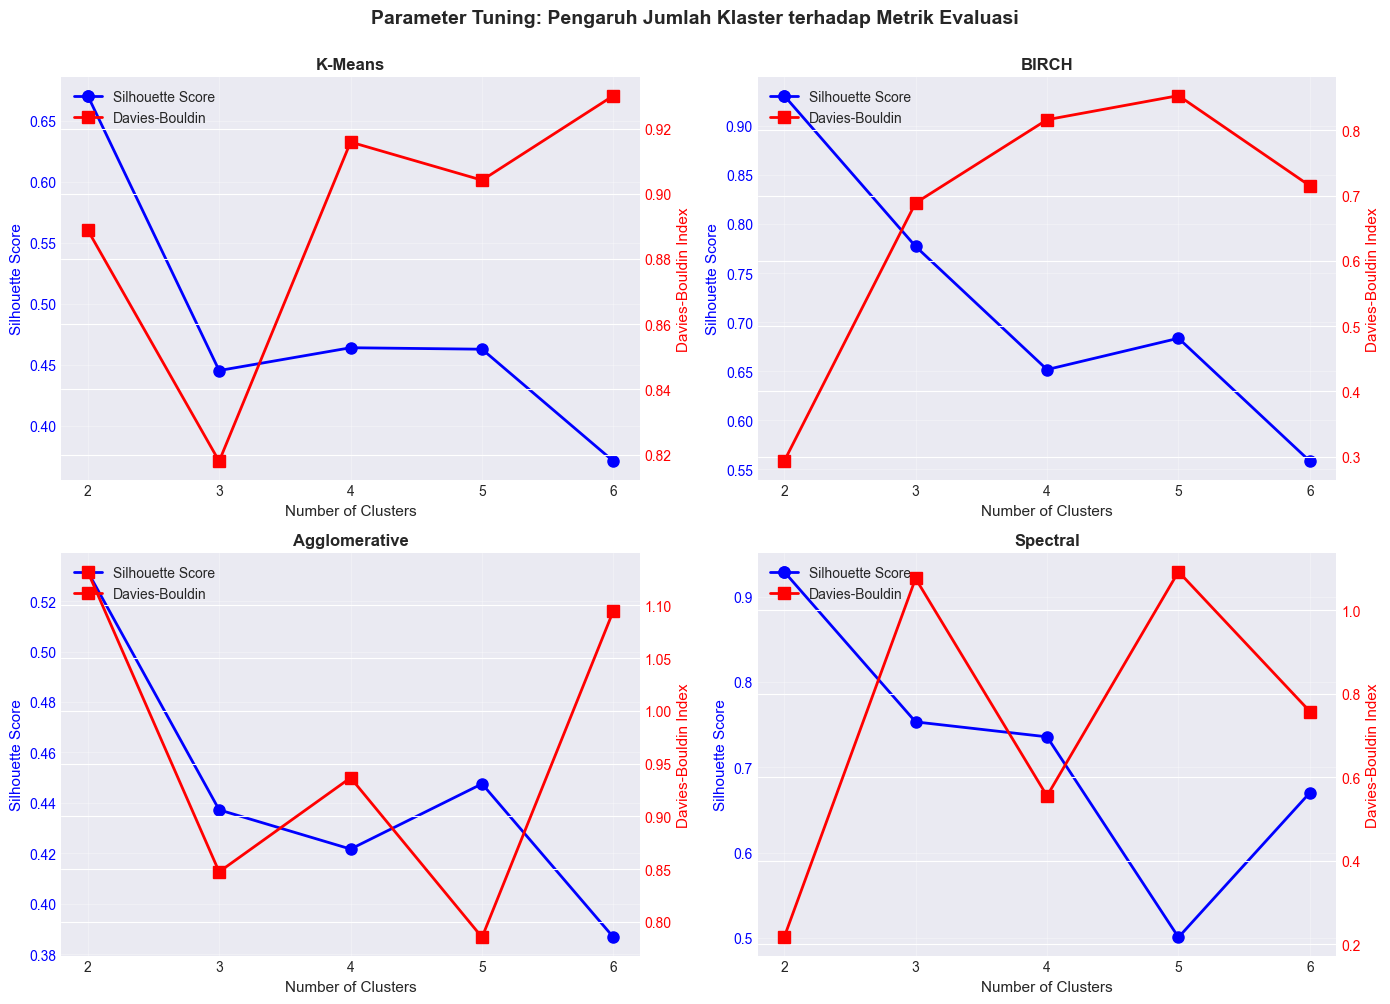


✓ Visualisasi parameter tuning selesai


In [23]:
# Visualisasi hasil parameter tuning
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Extract data untuk plotting
n_clust_vals = n_clusters_range
for idx, model_name in enumerate(model_names):
    row, col = divmod(idx, 2)
    ax = axes[row, col]
    
    sil_scores = [r['silhouette'] for r in tuning_results[model_name]]
    db_scores = [r['davies_bouldin'] for r in tuning_results[model_name]]
    
    ax2 = ax.twinx()
    
    # Silhouette Score (line)
    line1 = ax.plot(n_clust_vals, sil_scores, 'b-o', linewidth=2, markersize=8, label='Silhouette Score')
    ax.set_ylabel('Silhouette Score', color='b', fontsize=11)
    ax.tick_params(axis='y', labelcolor='b')
    ax.grid(alpha=0.3)
    
    # Davies-Bouldin (line)
    line2 = ax2.plot(n_clust_vals, db_scores, 'r-s', linewidth=2, markersize=8, label='Davies-Bouldin')
    ax2.set_ylabel('Davies-Bouldin Index', color='r', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='r')
    
    ax.set_xlabel('Number of Clusters', fontsize=11)
    ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
    ax.set_xticks(n_clust_vals)
    
    # Combine legends
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='upper left', fontsize=10)

plt.suptitle('Parameter Tuning: Pengaruh Jumlah Klaster terhadap Metrik Evaluasi', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n✓ Visualisasi parameter tuning selesai")

---

# 8. Kesimpulan & Rekomendasi

## Temuan Utama:

1. **Performa Model (n_clusters=3)**
   - Model dengan Silhouette Score tertinggi adalah yang paling optimal
   - Davies-Bouldin terendah menunjukkan clustering quality terbaik

2. **Pengaruh Preprocessing**
   - Mean Imputation secara efektif menangani missing values
   - Standardization (StandardScaler) penting untuk algoritma berbasis distance

3. **Pengaruh Parameter Tuning**
   - Variasi n_clusters menunjukkan trade-off antara simplicity dan separation
   - n_clusters optimal berbeda untuk setiap algoritma

4. **Karakteristik Algoritma**
   - **K-Means**: Cepat, intuitif, cocok untuk data yang well-separated
   - **BIRCH**: Efisien untuk dataset besar, hierarchical approach
   - **Agglomerative**: Fleksibel dengan linkage methods, memberikan dendrogram
   - **Spectral**: Powerful untuk non-linear clusters, lebih computation-intensive

## Rekomendasi Penggunaan:

- Untuk deteksi fraud dengan interpretability tinggi → **Agglomerative Clustering**
- Untuk scalability pada dataset besar → **BIRCH atau K-Means**
- Untuk complex pattern detection → **Spectral Clustering**
- Untuk balance antara performance & speed → **K-Means**

## Langkah Selanjutnya:

1. Eksperimen pada semua 5 dataset
2. Analisis cross-dataset consistency
3. Hyperparameter fine-tuning lebih lanjut
4. Ensemble methods untuk meningkatkan robustness
5. Implementasi real-time clustering pada aplikasi Streamlit

---

# 9. Catatan untuk Laporan Tertulis (Opsi B)

Jupyter Notebook ini dapat dikonversi ke laporan tertulis dengan struktur:

- **Bab 1 - Pendahuluan**: Background dan objektif eksperimen
- **Bab 2 - Penjelasan Algoritma**: Deskripsi 4 algoritma clustering
- **Bab 3 - Implementasi Program**: Code dari notebook sections 1-4
- **Bab 4 - Hasil Eksperimen**: Tabel dan grafik dari sections 5-7
- **Bab 5 - Analisis & Diskusi**: Interpretasi hasil dan perbandingan
- **Bab 6 - Kesimpulan**: Ringkasan findings dan recommendations

### Format Laporan:
- Export notebook menjadi PDF/HTML
- Atau salin konten markdown + code snippets ke Word/LaTeX
- Tambahkan teks penjelasan di antara sections
- Sertakan screenshots dari output visualisasi

### Kelengkapan Dokumentasi:
✓ Tahapan teknis berurutan (load → preprocess → train → evaluate)
✓ Preprocessing detail (Mean Imputation & Standardization)
✓ Feature selection logic
✓ Parameter tuning experiments
✓ Evaluasi metrik dengan penjelasan
✓ Visualisasi hasil clustering
✓ Analisis performa antar model
✓ Rekomendasi dan kesimpulan